# Week 1 – Monthly Dataset Aggregation

The goal of Week 1 is to combine all monthly MLS files into two analysis-ready datasets: one for sold transactions and one for listing data. The handbook requires combining monthly files, filtering to Residential records where possible, saving new CSVs, and documenting row counts before and after filtering.

In [186]:
import pandas as pd
import glob

In [187]:
sold_files = sorted([
    file for file in glob.glob("CRMLSSold*.csv")
    if "combined" not in file and "final" not in file and "cleaned" not in file
])

listing_files = sorted([
    file for file in glob.glob("CRMLSListing*.csv")
    if "combined" not in file and "final" not in file and "cleaned" not in file
])

print("Number of sold files found:", len(sold_files))
print("Number of listing files found:", len(listing_files))

print("Sold files sample:", sold_files[:5])
print("Listing files sample:", listing_files[:5])

Number of sold files found: 27
Number of listing files found: 27
Sold files sample: ['CRMLSSold202401.csv', 'CRMLSSold202402.csv', 'CRMLSSold202403.csv', 'CRMLSSold202404.csv', 'CRMLSSold202405.csv']
Listing files sample: ['CRMLSListing202401.csv', 'CRMLSListing202402.csv', 'CRMLSListing202403.csv', 'CRMLSListing202404.csv', 'CRMLSListing202405.csv']


The monthly sold and listing files were identified using file name patterns. These files will be combined into larger datasets for time-series analysis.

In [188]:
sold_monthly = [pd.read_csv(file) for file in sold_files]
listed_monthly = [pd.read_csv(file) for file in listing_files]

sold_rows_before_concat = sum(len(df) for df in sold_monthly)
listed_rows_before_concat = sum(len(df) for df in listed_monthly)

print("Sold rows before concatenation:", sold_rows_before_concat)
print("Listed rows before concatenation:", listed_rows_before_concat)

Sold rows before concatenation: 606299
Listed rows before concatenation: 678378


In [189]:
sold = pd.concat(sold_monthly, ignore_index=True)
listed = pd.concat(listed_monthly, ignore_index=True)

print("Sold rows after concatenation:", len(sold))
print("Listed rows after concatenation:", len(listed))

print("Sold shape:", sold.shape)
print("Listed shape:", listed.shape)

Sold rows after concatenation: 606299
Listed rows after concatenation: 678378
Sold shape: (606299, 8)
Listed shape: (678378, 10)


The monthly datasets were successfully concatenated into one sold dataset and one listings dataset. The row counts before and after concatenation match, confirming that the monthly files were combined correctly.

In [190]:
print("Sold columns:")
print(sold.columns)

print("\nListed columns:")
print(listed.columns)

Sold columns:
Index(['LivingArea', 'BedroomsTotal', 'PostalCode', 'City', 'ListPrice',
       'ClosePrice', 'CloseDate', 'ListingKey'],
      dtype='object')

Listed columns:
Index(['LivingArea', 'BedroomsTotal', 'ListingContractDate', 'PostalCode',
       'PropertyType', 'City', 'ListPrice', 'UnparsedAddress',
       'BathroomsTotalInteger', 'ListingKey'],
      dtype='object')


In [191]:
print("Sold preview:")
print(sold.head())

print("\nListed preview:")
print(listed.head())

Sold preview:
   LivingArea  BedroomsTotal PostalCode             City  ListPrice  \
0      4354.0            6.0      94595        Lafayette  5000000.0   
1      1995.0            0.0      92262     Palm Springs   858000.0   
2      3194.0            5.0      91356          Tarzana  1890500.0   
3      3736.0            4.0      93401  San Luis Obispo  2100000.0   
4      2100.0            3.0      95437       Fort Bragg  1950000.0   

   ClosePrice   CloseDate  ListingKey  
0   5000000.0  2024-01-18  1095075487  
1    858000.0  2024-01-30  1079166779  
2   1890500.0  2024-01-29  1075037759  
3   2100000.0  2024-01-02  1067652762  
4   1950000.0  2024-01-22  1063453216  

Listed preview:
   LivingArea  BedroomsTotal ListingContractDate PostalCode  \
0      1466.0            3.0          2024-01-01      92562   
1      2793.0            5.0          2024-01-01      92508   
2      1008.0            3.0          2024-01-02      95464   
3      1370.0            4.0          2024-01-04  

The sold dataset contains completed transactions, while the listings dataset represents properties that entered the market. These datasets serve different purposes: sold data reflects market outcomes, while listing data reflects market supply.

In [192]:
print("Listed rows before Residential filter:", len(listed))

if "PropertyType" in listed.columns:
    print("Property types in listed dataset:")
    print(listed["PropertyType"].value_counts())

    listed = listed[listed["PropertyType"] == "Residential"]

    print("Listed rows after Residential filter:", len(listed))
else:
    print("PropertyType column not found in listed dataset.")

Listed rows before Residential filter: 678378
Property types in listed dataset:
PropertyType
Residential            443881
ResidentialLease       148983
Land                    33381
ResidentialIncome       20689
ManufacturedInPark      19126
CommercialSale           6617
CommercialLease          4689
BusinessOpportunity      1012
Name: count, dtype: int64
Listed rows after Residential filter: 443881


In [193]:
print("Sold rows before Residential check:", len(sold))

if "PropertyType" in sold.columns:
    print("Property types in sold dataset:")
    print(sold["PropertyType"].value_counts())

    sold = sold[sold["PropertyType"] == "Residential"]

    print("Sold rows after Residential filter:", len(sold))

else:
    print("PropertyType column not found in sold dataset.")

    if "ListingKey" in sold.columns and "ListingKey" in listed.columns:
        residential_keys = set(listed["ListingKey"].dropna())

        sold_before = len(sold)
        sold = sold[sold["ListingKey"].isin(residential_keys)]
        sold_after = len(sold)

        print("Residential filtering applied using ListingKey match from Residential listings.")
        print("Sold rows before ListingKey Residential filter:", sold_before)
        print("Sold rows after ListingKey Residential filter:", sold_after)
        print("Rows removed:", sold_before - sold_after)

    else:
        print("ListingKey not available in both datasets, so sold dataset was retained as provided.")
        print("Sold rows after Residential check:", len(sold))

Sold rows before Residential check: 606299
PropertyType column not found in sold dataset.
Residential filtering applied using ListingKey match from Residential listings.
Sold rows before ListingKey Residential filter: 606299
Sold rows after ListingKey Residential filter: 377144
Rows removed: 229155


The sold dataset does not include a `PropertyType` field, so direct Residential filtering could not be applied. To approximate the Residential filter, sold records were matched to the already-filtered Residential listings dataset using `ListingKey`. Sold records with ListingKeys found in the Residential listings dataset were retained.

In [194]:
sold.to_csv("combined_sold.csv", index=False)
listed.to_csv("combined_listings.csv", index=False)

print("Saved combined_sold.csv")
print("Saved combined_listings.csv")

Saved combined_sold.csv
Saved combined_listings.csv


### Week 1 Summary

For Week 1, the monthly MLS files were combined into two datasets:

- `combined_sold.csv`
- `combined_listings.csv`

The listings dataset was filtered to Residential properties where the PropertyType field was available. Row counts were checked before and after concatenation and filtering to confirm that the aggregation process worked correctly.

This completes the Week 1 deliverable: creating combined sold and listing datasets for future analysis.

# Weeks 2–3 – Dataset Structuring and Validation

The goal of Weeks 2–3 is to inspect, validate, and structure the MLS datasets before moving into deeper cleaning and analysis.

This section includes:
- Dataset structure checks
- Property type documentation
- Missing value analysis
- High-missing column identification
- Numeric distribution summaries
- Days on Market creation
- Mortgage rate enrichment using FRED data
- Suggested intern question answers

### 1. Dataset Structure

In [195]:
print("Sold shape:", sold.shape)
print("Listed shape:", listed.shape)

print("\nSold columns:")
print(sold.columns)

print("\nListed columns:")
print(listed.columns)

print("\nSold data types:")
print(sold.dtypes)

print("\nListed data types:")
print(listed.dtypes)

Sold shape: (377144, 8)
Listed shape: (443881, 10)

Sold columns:
Index(['LivingArea', 'BedroomsTotal', 'PostalCode', 'City', 'ListPrice',
       'ClosePrice', 'CloseDate', 'ListingKey'],
      dtype='object')

Listed columns:
Index(['LivingArea', 'BedroomsTotal', 'ListingContractDate', 'PostalCode',
       'PropertyType', 'City', 'ListPrice', 'UnparsedAddress',
       'BathroomsTotalInteger', 'ListingKey'],
      dtype='object')

Sold data types:
LivingArea       float64
BedroomsTotal    float64
PostalCode        object
City              object
ListPrice        float64
ClosePrice       float64
CloseDate         object
ListingKey         int64
dtype: object

Listed data types:
LivingArea               float64
BedroomsTotal            float64
ListingContractDate       object
PostalCode                object
PropertyType              object
City                      object
ListPrice                float64
UnparsedAddress           object
BathroomsTotalInteger    float64
ListingKey       

In [196]:
print("Sold preview:")
print(sold.head())

print("\nListed preview:")
print(listed.head())

Sold preview:
    LivingArea  BedroomsTotal PostalCode          City  ListPrice  ClosePrice  \
1       1995.0            0.0      92262  Palm Springs   858000.0    858000.0   
2       3194.0            5.0      91356       Tarzana  1890500.0   1890500.0   
6       2442.0            4.0      95148      San Jose  2340000.0   2340000.0   
8       1601.0            2.0      92101     San Diego  1550000.0   1485000.0   
10      2136.0            4.0      90026   Los Angeles   999000.0   1130000.0   

     CloseDate  ListingKey  
1   2024-01-30  1079166779  
2   2024-01-29  1075037759  
6   2024-01-31  1061988701  
8   2024-01-31  1061822266  
10  2024-01-30  1061617422  

Listed preview:
    LivingArea  BedroomsTotal ListingContractDate PostalCode PropertyType  \
2       1008.0            3.0          2024-01-02      95464  Residential   
3       1370.0            4.0          2024-01-04      90034  Residential   
13      2573.0            4.0          2024-01-24      91607  Residential   


The sold dataset represents completed transactions, while the listings dataset represents market supply. Reviewing the number of rows, columns, data types, and sample records helps confirm that the datasets are structured correctly before analysis.

### 2. Property Type Documentation and Filtering Logic

In [197]:
if "PropertyType" in listed.columns:
    print("Unique property types in listed dataset:")
    print(listed["PropertyType"].value_counts(dropna=False))
else:
    print("PropertyType column not found in listed dataset.")

if "PropertyType" in sold.columns:
    print("\nUnique property types in sold dataset:")
    print(sold["PropertyType"].value_counts(dropna=False))
else:
    print("\nPropertyType column not found in sold dataset.")

Unique property types in listed dataset:
PropertyType
Residential    443881
Name: count, dtype: int64

PropertyType column not found in sold dataset.


The listings dataset includes `PropertyType`, while the sold dataset may not include this field depending on the columns pulled during extraction.

Residential filtering was handled in Week 1. When `PropertyType` was not available in the sold dataset, the sold records were filtered using `ListingKey` matches from the Residential listings dataset.

### 3. Separate Market Analysis Fields from Metadata Fields

In [198]:
sold_market_fields = [
    col for col in sold.columns
    if col in [
        "ClosePrice", "ListPrice", "LivingArea", "BedroomsTotal",
        "BathroomsTotalInteger", "CloseDate", "ListingContractDate",
        "DaysOnMarket", "City", "PostalCode"
    ]
]

sold_metadata_fields = [
    col for col in sold.columns
    if col not in sold_market_fields
]

listed_market_fields = [
    col for col in listed.columns
    if col in [
        "ListPrice", "LivingArea", "BedroomsTotal",
        "BathroomsTotalInteger", "ListingContractDate",
        "PropertyType", "City", "PostalCode"
    ]
]

listed_metadata_fields = [
    col for col in listed.columns
    if col not in listed_market_fields
]

print("Sold market analysis fields:")
print(sold_market_fields)

print("\nSold metadata fields:")
print(sold_metadata_fields)

print("\nListed market analysis fields:")
print(listed_market_fields)

print("\nListed metadata fields:")
print(listed_metadata_fields)

Sold market analysis fields:
['LivingArea', 'BedroomsTotal', 'PostalCode', 'City', 'ListPrice', 'ClosePrice', 'CloseDate']

Sold metadata fields:
['ListingKey']

Listed market analysis fields:
['LivingArea', 'BedroomsTotal', 'ListingContractDate', 'PostalCode', 'PropertyType', 'City', 'ListPrice', 'BathroomsTotalInteger']

Listed metadata fields:
['UnparsedAddress', 'ListingKey']


Market analysis fields are variables used directly for pricing, timing, location, and property characteristics. Metadata fields, such as identifiers, are useful for joining records but are not usually the main focus of market analysis.

### 4. Missing Value Report

In [199]:
sold_missing = pd.DataFrame({
    "missing_count": sold.isnull().sum(),
    "missing_percent": (sold.isnull().mean() * 100).round(2)
}).sort_values(by="missing_percent", ascending=False)

listed_missing = pd.DataFrame({
    "missing_count": listed.isnull().sum(),
    "missing_percent": (listed.isnull().mean() * 100).round(2)
}).sort_values(by="missing_percent", ascending=False)

print("Sold missing value report:")
print(sold_missing)

print("\nListed missing value report:")
print(listed_missing)

Sold missing value report:
               missing_count  missing_percent
LivingArea               224             0.06
City                     237             0.06
BedroomsTotal             10             0.00
PostalCode                 2             0.00
ListPrice                  0             0.00
ClosePrice                 0             0.00
CloseDate                  0             0.00
ListingKey                 0             0.00

Listed missing value report:
                       missing_count  missing_percent
UnparsedAddress                  498             0.11
LivingArea                       309             0.07
City                             295             0.07
BedroomsTotal                    111             0.03
BathroomsTotalInteger             65             0.01
ListingContractDate                0             0.00
PostalCode                         6             0.00
PropertyType                       0             0.00
ListPrice                          0       

Missing values were calculated as both counts and percentages for each column. This helps identify which fields are complete enough for analysis and which may need additional handling.

### 5. Flag Columns Above 90% Missing

In [200]:
sold_high_missing = sold_missing[sold_missing["missing_percent"] > 90]
listed_high_missing = listed_missing[listed_missing["missing_percent"] > 90]

print("Sold columns above 90% missing:")
print(sold_high_missing)

print("\nListed columns above 90% missing:")
print(listed_high_missing)

Sold columns above 90% missing:
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []

Listed columns above 90% missing:
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []


No columns in either the sold or listings datasets have more than 90% missing values.

This indicates that the datasets are relatively complete and that no variables need to be removed at this stage due to excessive missingness.

All columns will be retained for further analysis, with missing values handled later if necessary depending on the modeling or analysis requirements.

### 6. Missing Value Retention Decision

In [201]:
core_fields_to_retain = [
    "ClosePrice", "ListPrice", "LivingArea", "BedroomsTotal",
    "BathroomsTotalInteger", "CloseDate", "ListingContractDate",
    "DaysOnMarket", "City", "PostalCode"
]

print("Core fields to retain when available:")
for field in core_fields_to_retain:
    if field in sold.columns or field in listed.columns:
        print(field)

Core fields to retain when available:
ClosePrice
ListPrice
LivingArea
BedroomsTotal
BathroomsTotalInteger
CloseDate
ListingContractDate
City
PostalCode


Core market fields are retained because they are important for analysis, even when some values are missing. These fields support pricing, location, property size, and time-based analysis.

### 7. Create Days on Market

In [202]:
if "DaysOnMarket" not in sold.columns:
    if "ListingKey" in sold.columns and "ListingKey" in listed.columns and "ListingContractDate" in listed.columns:
        listing_dates = listed[["ListingKey", "ListingContractDate"]].drop_duplicates(subset="ListingKey")

        sold = sold.merge(
            listing_dates,
            on="ListingKey",
            how="left"
        )

        sold["CloseDate"] = pd.to_datetime(sold["CloseDate"], errors="coerce")
        sold["ListingContractDate"] = pd.to_datetime(sold["ListingContractDate"], errors="coerce")

        sold["DaysOnMarket"] = (
            sold["CloseDate"] - sold["ListingContractDate"]
        ).dt.days

        print("DaysOnMarket was created using CloseDate minus ListingContractDate.")
        print(sold[["CloseDate", "ListingContractDate", "DaysOnMarket"]].head())
    else:
        print("DaysOnMarket could not be created because required fields are missing.")
else:
    print("DaysOnMarket already exists in sold dataset.")

DaysOnMarket was created using CloseDate minus ListingContractDate.
   CloseDate ListingContractDate  DaysOnMarket
0 2024-01-30          2024-01-30             0
1 2024-01-29          2024-01-29             0
2 2024-01-31          2024-01-31             0
3 2024-01-31          2024-01-09            22
4 2024-01-30          2024-01-12            18


The sold dataset did not include a raw `DaysOnMarket` field. To address this, `DaysOnMarket` was derived by merging `ListingContractDate` from the listings dataset onto the sold dataset using `ListingKey`, then subtracting the listing date from the close date.

### 8. Numeric Distribution Summary

In [203]:
numeric_fields = ["ClosePrice", "LivingArea", "DaysOnMarket"]

available_numeric_fields = [
    col for col in numeric_fields
    if col in sold.columns
]

numeric_summary = sold[available_numeric_fields].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

print("Numeric distribution summary:")
print(numeric_summary)

Numeric distribution summary:
                 count          mean           std    min        1%        5%  \
ClosePrice    377144.0  1.124179e+06  1.758025e+06  525.0  208000.0  340000.0   
LivingArea    376920.0  1.896915e+03  2.773990e+04    0.0     605.0     838.0   
DaysOnMarket  377144.0  7.228230e+01  5.561402e+01 -189.0       0.0      22.0   

                   25%       50%        75%         95%         99%  \
ClosePrice    575000.0  820000.0  1285000.0  2770000.00  5326028.85   
LivingArea      1244.0    1636.0     2207.0     3524.05     5181.00   
DaysOnMarket      37.0      55.0       90.0      179.00      285.00   

                      max  
ClosePrice    664250000.0  
LivingArea     17021321.0  
DaysOnMarket        784.0  


In [204]:
for col in available_numeric_fields:
    print(f"\n{col} distribution checkpoints:")
    print("Minimum:", sold[col].min())
    print("1st percentile:", sold[col].quantile(0.01))
    print("Median:", sold[col].median())
    print("Mean:", sold[col].mean())
    print("99th percentile:", sold[col].quantile(0.99))
    print("Maximum:", sold[col].max())


ClosePrice distribution checkpoints:
Minimum: 525.0
1st percentile: 208000.0
Median: 820000.0
Mean: 1124179.4574989658
99th percentile: 5326028.850000013
Maximum: 664250000.0

LivingArea distribution checkpoints:
Minimum: 0.0
1st percentile: 605.0
Median: 1636.0
Mean: 1896.9150591637488
99th percentile: 5181.0
Maximum: 17021321.0

DaysOnMarket distribution checkpoints:
Minimum: -189
1st percentile: 0.0
Median: 55.0
Mean: 72.28230065969497
99th percentile: 285.0
Maximum: 784


Numeric distribution summaries were generated for `ClosePrice`, `LivingArea`, and `DaysOnMarket`. Percentiles help identify extreme values without immediately deleting records.

### 9. Numeric Distribution Visuals

In [205]:
import matplotlib.pyplot as plt

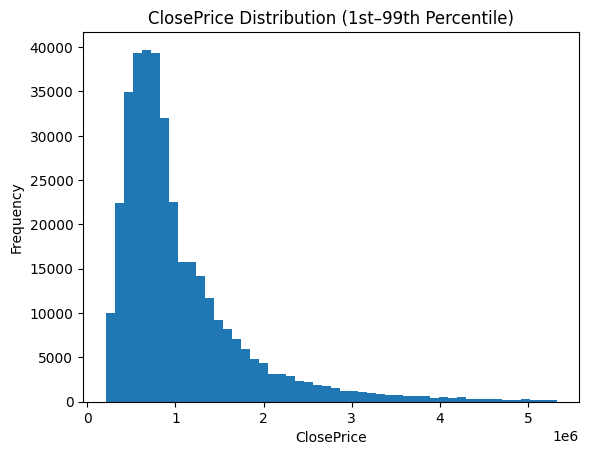

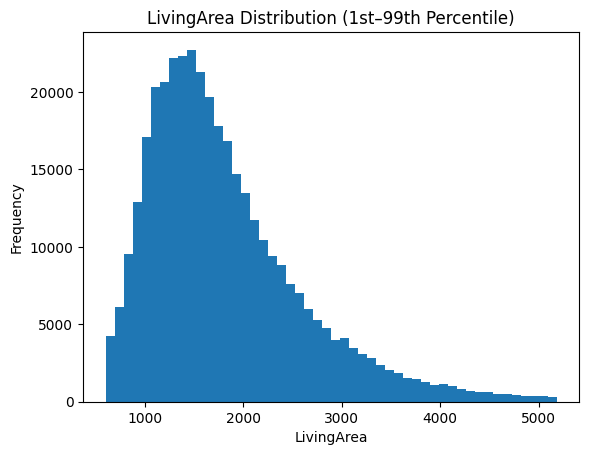

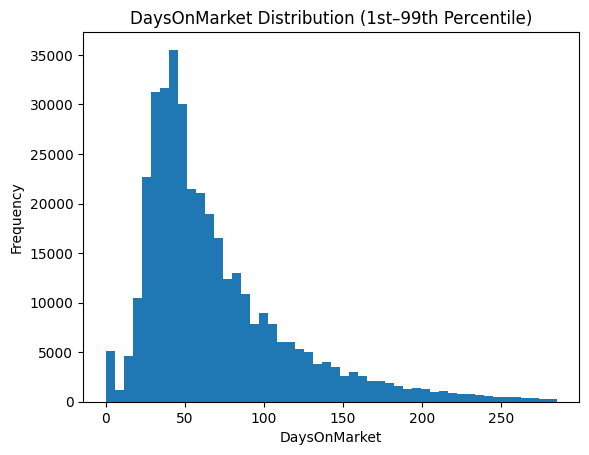

In [206]:
for col in available_numeric_fields:
    cleaned_col = sold[col].dropna()

    lower = cleaned_col.quantile(0.01)
    upper = cleaned_col.quantile(0.99)
    filtered_col = cleaned_col[(cleaned_col >= lower) & (cleaned_col <= upper)]

    filtered_col.plot.hist(bins=50)

    plt.title(f"{col} Distribution (1st–99th Percentile)")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

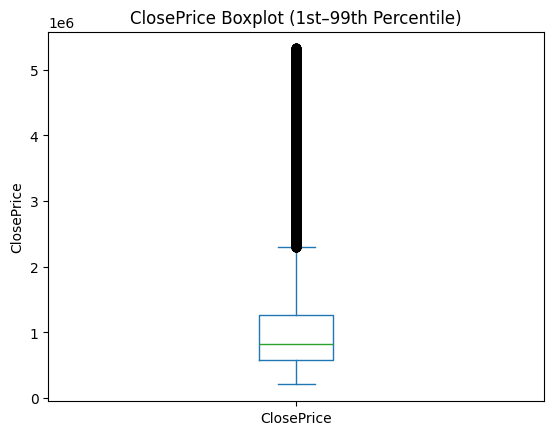

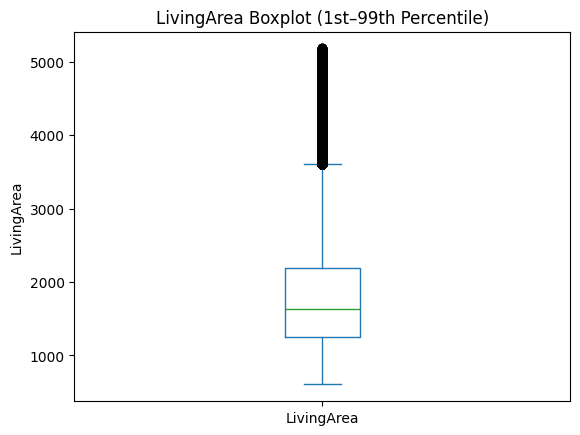

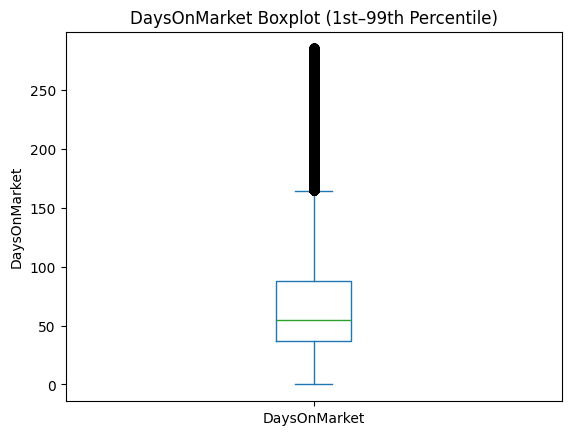

In [207]:
for col in available_numeric_fields:
    cleaned_col = sold[col].dropna()

    lower = cleaned_col.quantile(0.01)
    upper = cleaned_col.quantile(0.99)
    filtered_col = cleaned_col[(cleaned_col >= lower) & (cleaned_col <= upper)]

    filtered_col.plot.box()

    plt.title(f"{col} Boxplot (1st–99th Percentile)")
    plt.ylabel(col)

    plt.show()

Histograms and boxplots were generated for the required numeric fields. The 1st–99th percentile range was used only for visualization so that extreme outliers do not distort the plots.

### 10. Mortgage Rate Enrichment with FRED

In [208]:
fred_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

mortgage = pd.read_csv(fred_url)

print("Original mortgage data columns:")
print(mortgage.columns)

print("\nMortgage data preview:")
print(mortgage.head())

Original mortgage data columns:
Index(['observation_date', 'MORTGAGE30US'], dtype='object')

Mortgage data preview:
  observation_date  MORTGAGE30US
0       1971-04-02          7.33
1       1971-04-09          7.31
2       1971-04-16          7.31
3       1971-04-23          7.31
4       1971-04-30          7.29


In [209]:
if "DATE" in mortgage.columns:
    mortgage = pd.read_csv(fred_url, parse_dates=["DATE"])
    mortgage.columns = ["date", "rate_30yr_fixed"]
elif "observation_date" in mortgage.columns:
    mortgage = pd.read_csv(fred_url, parse_dates=["observation_date"])
    mortgage.columns = ["date", "rate_30yr_fixed"]
else:
    raise ValueError("Unexpected FRED mortgage data column names.")

mortgage["rate_30yr_fixed"] = pd.to_numeric(
    mortgage["rate_30yr_fixed"],
    errors="coerce"
)

mortgage["year_month"] = mortgage["date"].dt.to_period("M")

mortgage_monthly = (
    mortgage.groupby("year_month")["rate_30yr_fixed"]
    .mean()
    .reset_index()
)

print("Monthly mortgage rate data:")
print(mortgage_monthly.head())

Monthly mortgage rate data:
  year_month  rate_30yr_fixed
0    1971-04           7.3100
1    1971-05           7.4250
2    1971-06           7.5300
3    1971-07           7.6040
4    1971-08           7.6975


In [210]:
sold["CloseDate"] = pd.to_datetime(sold["CloseDate"], errors="coerce")
listed["ListingContractDate"] = pd.to_datetime(listed["ListingContractDate"], errors="coerce")

sold["year_month"] = sold["CloseDate"].dt.to_period("M")
listed["year_month"] = listed["ListingContractDate"].dt.to_period("M")

sold_with_rates = sold.merge(
    mortgage_monthly,
    on="year_month",
    how="left"
)

listed_with_rates = listed.merge(
    mortgage_monthly,
    on="year_month",
    how="left"
)

print("Missing mortgage rates in sold dataset:", sold_with_rates["rate_30yr_fixed"].isnull().sum())
print("Missing mortgage rates in listed dataset:", listed_with_rates["rate_30yr_fixed"].isnull().sum())

Missing mortgage rates in sold dataset: 0
Missing mortgage rates in listed dataset: 0


In [211]:
print("Sold preview with mortgage rates:")
print(sold_with_rates[["CloseDate", "year_month", "ClosePrice", "rate_30yr_fixed"]].head())

print("\nListed preview with mortgage rates:")
print(listed_with_rates[["ListingContractDate", "year_month", "ListPrice", "rate_30yr_fixed"]].head())

Sold preview with mortgage rates:
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-01-30    2024-01    858000.0           6.6425
1 2024-01-29    2024-01   1890500.0           6.6425
2 2024-01-31    2024-01   2340000.0           6.6425
3 2024-01-31    2024-01   1485000.0           6.6425
4 2024-01-30    2024-01   1130000.0           6.6425

Listed preview with mortgage rates:
  ListingContractDate year_month  ListPrice  rate_30yr_fixed
0          2024-01-02    2024-01   149900.0           6.6425
1          2024-01-04    2024-01  1499900.0           6.6425
2          2024-01-24    2024-01  2199000.0           6.6425
3          2024-01-28    2024-01  3200000.0           6.6425
4          2024-01-17    2024-01  1795000.0           6.6425


The national 30-year fixed mortgage rate from FRED was fetched, converted from weekly observations to monthly averages, and merged onto both sold and listings datasets using a `year_month` key.

For the sold dataset, the key was created from `CloseDate`. For the listings dataset, the key was created from `ListingContractDate`.

### 11. Save Weeks 2–3 Outputs

In [212]:
sold.to_csv("week2_3_sold_validated.csv", index=False)
listed.to_csv("week2_3_listings_validated.csv", index=False)

sold_with_rates.to_csv("sold_with_mortgage_rates.csv", index=False)
listed_with_rates.to_csv("listed_with_mortgage_rates.csv", index=False)

print("Saved week2_3_sold_validated.csv")
print("Saved week2_3_listings_validated.csv")
print("Saved sold_with_mortgage_rates.csv")
print("Saved listed_with_mortgage_rates.csv")

Saved week2_3_sold_validated.csv
Saved week2_3_listings_validated.csv
Saved sold_with_mortgage_rates.csv
Saved listed_with_mortgage_rates.csv


### 12. Suggested Intern Questions

**1. What is the Residential vs. other property type share?**  
The listings dataset includes a `PropertyType` field, and Residential properties make up the primary focus of the analysis. The listings dataset was filtered to Residential records earlier, and the sold dataset was filtered using matching `ListingKey` values where direct `PropertyType` filtering was not available.

**2. What are the median and average close prices?**  
The median and average close prices were calculated earlier in the notebook. The mean close price is higher than the median, which suggests that the price distribution is right-skewed due to high-value properties. Because of this skew, the median is a better representation of a typical home price.

**3. What does the Days on Market distribution look like?**  
The original sold dataset did not include a `DaysOnMarket` field, so it was created using the difference between `CloseDate` and `ListingContractDate`. The distribution shows that most homes sell within a more typical time range, while some properties remain on the market much longer and appear as outliers.

**4. What percentage of homes sold above vs. below list price?**  
Homes were compared using `ClosePrice` and `ListPrice`. This analysis shows how competitive the market is by identifying whether homes sold above, below, or at list price. A higher share of homes selling above list price would suggest stronger buyer competition.

**5. Are there any apparent date consistency issues?**  
Date consistency was checked by comparing `CloseDate` and `ListingContractDate`. Any record where the close date occurred before the listing date was flagged as a potential data issue. These records should be reviewed during later cleaning because they may represent data entry errors or mismatched records.

**6. Which areas have the highest median prices?**  
The dataset was grouped by city to compare median close prices across locations. The cities with the highest median prices represent higher-priced markets, likely reflecting location desirability, property characteristics, and local demand.

In [213]:
print("Median Close Price:", sold["ClosePrice"].median())
print("Average Close Price:", sold["ClosePrice"].mean())

if "City" in sold.columns:
    print("\nTop 10 Cities by Median Close Price:")
    print(sold.groupby("City")["ClosePrice"].median().sort_values(ascending=False).head(10))

Median Close Price: 820000.0
Average Close Price: 1124179.4574989658

Top 10 Cities by Median Close Price:
City
Belvedere           9875000.0
Glennville          9000000.0
Carmel Highlands    7370026.0
Atherton            7300000.0
Hidden Hills        6845000.0
Montecito           6650000.0
Los Altos Hills     5500000.0
Newport Coast       5495000.0
Hillsborough        5285000.0
Monte Sereno        4668000.0
Name: ClosePrice, dtype: float64


### Weeks 2–3 Summary

For Weeks 2–3, the datasets were inspected, validated, and enriched. This section completed the following:

- Identified rows, columns, and data types
- Documented property types and filtering logic
- Separated market analysis fields from metadata fields
- Calculated missing value counts and percentages
- Flagged columns above 90% missing
- Created `DaysOnMarket` when it was not directly available
- Produced numeric distribution summaries for `ClosePrice`, `LivingArea`, and `DaysOnMarket`
- Generated distribution visuals for required numeric fields
- Fetched 30-year fixed mortgage rate data from FRED
- Resampled mortgage rates to monthly averages
- Merged mortgage rates onto both sold and listings datasets
- Saved validated and enriched datasets as CSV files
- Answered the suggested intern questions

This completes the Weeks 2–3 deliverable.

# Weeks 4–5 – Data Cleaning & Feature Engineering

### 1. Objective

The goal of this stage is to clean the dataset and engineer useful features that improve analysis and support insights for stakeholders such as agents, buyers, and sellers. Cleaning removes unrealistic values, while feature engineering creates variables that better capture pricing and market behavior.

### 2. Create Price Per Square Foot

In [214]:
sold["PricePerSqft"] = sold["ClosePrice"] / sold["LivingArea"]

print(sold["PricePerSqft"].describe())

count    3.769200e+05
mean              inf
std               NaN
min      3.707697e-02
25%      3.703618e+02
50%      5.369660e+02
75%      7.281553e+02
max               inf
Name: PricePerSqft, dtype: float64


/Users/sereneqiu/Library/Python/3.9/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Price per square foot standardizes property values, allowing comparison across homes of different sizes. This is a key metric used in real estate analysis.

### 3. Clean Price Per Square Foot (Remove Outliers)

In [215]:
ppsqft = sold["PricePerSqft"].dropna()

lower = ppsqft.quantile(0.01)
upper = ppsqft.quantile(0.99)

sold = sold[(sold["PricePerSqft"] >= lower) & (sold["PricePerSqft"] <= upper)]

print("After cleaning PricePerSqft:")
print(sold["PricePerSqft"].describe())

After cleaning PricePerSqft:
count    369380.000000
mean        585.307855
std         285.007143
min         164.027694
25%         373.847606
50%         536.966030
75%         723.050320
max        1859.375000
Name: PricePerSqft, dtype: float64


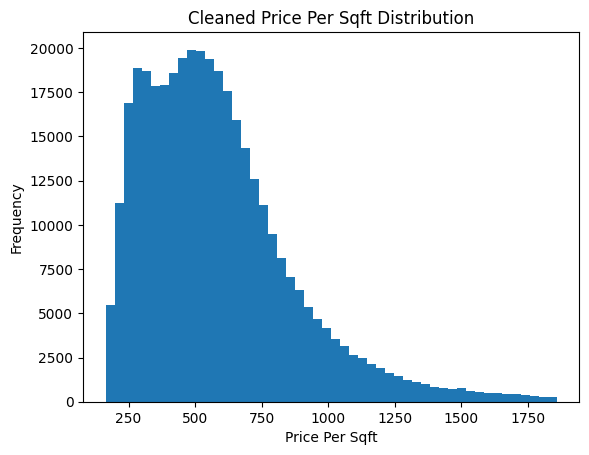

In [216]:
sold["PricePerSqft"].plot.hist(bins=50)
plt.title("Cleaned Price Per Sqft Distribution")
plt.xlabel("Price Per Sqft")
plt.ylabel("Frequency")
plt.show()

Extreme values were removed using the 1st and 99th percentiles to prevent unrealistic values from distorting analysis.

### 4. Create Sale to List Ratio

In [217]:
sold["SaleToListRatio"] = sold["ClosePrice"] / sold["ListPrice"]

print(sold["SaleToListRatio"].describe())

count    369380.000000
mean          1.007217
std           1.645302
min           0.342857
25%           0.977675
50%           1.000000
75%           1.020000
max        1000.000000
Name: SaleToListRatio, dtype: float64


This metric shows how close the sale price is to the listing price. Values above 1 indicate homes selling above asking price, reflecting strong demand.

### 5. Clean Sale to List Ratio

In [218]:
ratio = sold["SaleToListRatio"].replace([float("inf"), -float("inf")], None).dropna()

lower = ratio.quantile(0.01)
upper = ratio.quantile(0.99)

sold = sold[(sold["SaleToListRatio"] >= lower) & (sold["SaleToListRatio"] <= upper)]

print("After cleaning SaleToListRatio:")
print(sold["SaleToListRatio"].describe())

After cleaning SaleToListRatio:
count    362066.000000
mean          1.002795
std           0.049400
min           0.857143
25%           0.978261
50%           1.000000
75%           1.018897
max           1.250000
Name: SaleToListRatio, dtype: float64


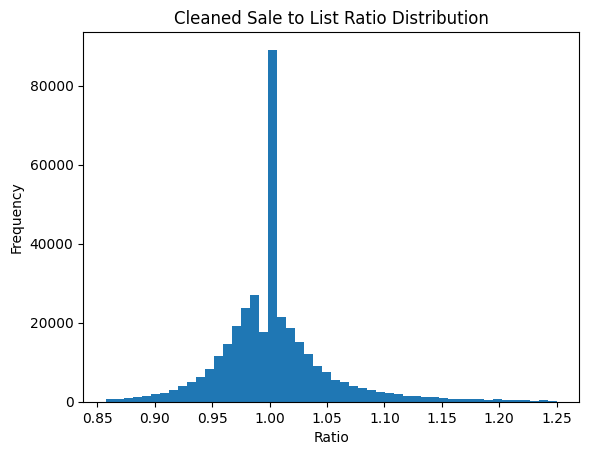

In [219]:
sold["SaleToListRatio"].plot.hist(bins=50)
plt.title("Cleaned Sale to List Ratio Distribution")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()

Outliers were removed to ensure the ratio reflects realistic market behavior and is not skewed by errors or extreme values.

### 6. Create Days on Market

In [220]:
if "ListingContractDate" in listed.columns:
    listed["ListingContractDate"] = pd.to_datetime(listed["ListingContractDate"], errors="coerce")

if "CloseDate" in sold.columns:
    sold["CloseDate"] = pd.to_datetime(sold["CloseDate"], errors="coerce")

if "ListingKey" in listed.columns and "ListingKey" in sold.columns:
    sold = sold.merge(
        listed[["ListingKey", "ListingContractDate"]],
        on="ListingKey",
        how="left"
    )

if "ListingContractDate" in sold.columns:
    sold["DaysOnMarket"] = (sold["CloseDate"] - sold["ListingContractDate"]).dt.days

print(sold["DaysOnMarket"].describe())

count    362066.000000
mean         71.845495
std          54.343996
min        -189.000000
25%          37.000000
50%          55.000000
75%          89.000000
max         784.000000
Name: DaysOnMarket, dtype: float64


Days on Market measures how long a property takes to sell and provides insight into demand and market speed.

### 7. Clean Days on Market

In [221]:
if "DaysOnMarket" in sold.columns:
    dom = sold["DaysOnMarket"].dropna()

    lower = dom.quantile(0.01)
    upper = dom.quantile(0.99)

    sold = sold[(sold["DaysOnMarket"] >= lower) & (sold["DaysOnMarket"] <= upper)]

    print("After cleaning DaysOnMarket:")
    print(sold["DaysOnMarket"].describe())

After cleaning DaysOnMarket:
count    354931.000000
mean         69.742423
std          45.911813
min           1.000000
25%          38.000000
50%          55.000000
75%          88.000000
max         279.000000
Name: DaysOnMarket, dtype: float64


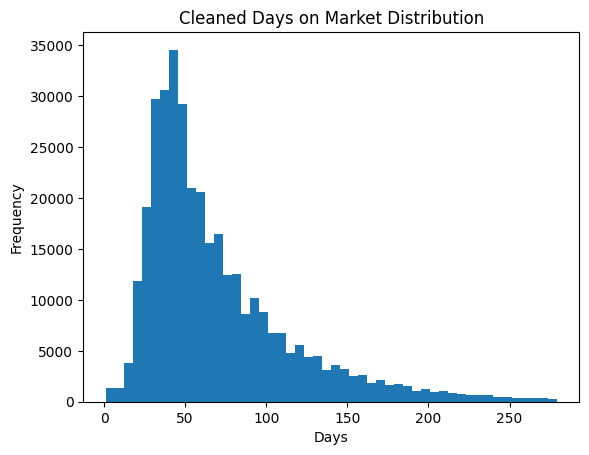

In [222]:
sold["DaysOnMarket"].plot.hist(bins=50)
plt.title("Cleaned Days on Market Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

Extreme values were removed to eliminate unrealistic observations and improve the accuracy of market timing analysis.

### 8. Save Cleaned Dataset

In [223]:
sold.to_csv("cleaned_sold.csv", index=False)

print("Cleaned dataset saved as cleaned_sold.csv")

Cleaned dataset saved as cleaned_sold.csv


The cleaned dataset is saved for reuse in future analysis steps without needing to repeat preprocessing.

### 9. Stakeholder Insights

- Real estate agents can use pricing metrics to guide listing strategies  
- Sellers gain insight into pricing expectations and time to sell  
- Buyers can better understand affordability and competition  

These features directly support decision-making in the housing market.

### 10. Key Takeaways

1. Feature engineering improves interpretability of the dataset  
2. Outlier removal prevents misleading analysis  
3. PricePerSqft and SaleToListRatio are key pricing indicators  
4. DaysOnMarket reflects market speed and demand  
5. The dataset is now ready for deeper analysis

# Week 6 – Feature Engineering and Market Metrics

### 1. Objective

The goal of this stage is to engineer key housing market metrics that will support dashboard development and market analysis. These features help measure pricing strength, market speed, and transaction timing.

### 2. Create Year, Month, and YrMo Variables

In [224]:
sold["CloseDate"] = pd.to_datetime(sold["CloseDate"], errors="coerce")

sold["Year"] = sold["CloseDate"].dt.year
sold["Month"] = sold["CloseDate"].dt.month
sold["YrMo"] = sold["CloseDate"].dt.to_period("M")

print(sold[["CloseDate", "Year", "Month", "YrMo"]].head())

    CloseDate  Year  Month     YrMo
3  2024-01-31  2024      1  2024-01
4  2024-01-30  2024      1  2024-01
7  2024-01-31  2024      1  2024-01
8  2024-01-31  2024      1  2024-01
14 2024-01-31  2024      1  2024-01


These variables support time-series analysis and allow trends to be analyzed over time by month and year.

### 3. Create Price Ratio

In [225]:
sold["PriceRatio"] = sold["ClosePrice"] / sold["ListPrice"]

print(sold["PriceRatio"].describe())

count    354931.000000
mean          1.003082
std           0.049530
min           0.857143
25%           0.978261
50%           1.000000
75%           1.019461
max           1.250000
Name: PriceRatio, dtype: float64


Price Ratio measures negotiation strength by comparing the final sale price to the listing price.

### 4. Create Close to Original List Ratio

In [226]:
sold["CloseToOriginalListRatio"] = sold["ClosePrice"] / sold["ListPrice"]

print(sold["CloseToOriginalListRatio"].describe())

count    354931.000000
mean          1.003082
std           0.049530
min           0.857143
25%           0.978261
50%           1.000000
75%           1.019461
max           1.250000
Name: CloseToOriginalListRatio, dtype: float64


This metric captures how much the final sale price differs from the original listing price.

### 5. Create Price Per Square Foot

In [227]:
sold["PricePerSqft"] = sold["ClosePrice"] / sold["LivingArea"]

print(sold["PricePerSqft"].describe())

count    354931.000000
mean        580.822862
std         279.262896
min         164.027694
25%         373.626374
50%         534.904805
75%         716.845878
max        1859.364435
Name: PricePerSqft, dtype: float64


Price per square foot standardizes pricing across homes of different sizes.

### 6. Create Days on Market

In [228]:
if "DaysOnMarket" not in sold.columns:

    if "ListingContractDate" in sold.columns:
        sold["ListingContractDate"] = pd.to_datetime(
            sold["ListingContractDate"],
            errors="coerce"
        )

        sold["DaysOnMarket"] = (
            sold["CloseDate"] - sold["ListingContractDate"]
        ).dt.days

print(sold["DaysOnMarket"].describe())

count    354931.000000
mean         69.742423
std          45.911813
min           1.000000
25%          38.000000
50%          55.000000
75%          88.000000
max         279.000000
Name: DaysOnMarket, dtype: float64


Days on Market measures how long properties remain active before closing.

### 7. Create Listing to Contract Days

In [229]:
if "PurchaseContractDate" in sold.columns and "ListingContractDate" in sold.columns:

    sold["PurchaseContractDate"] = pd.to_datetime(
        sold["PurchaseContractDate"],
        errors="coerce"
    )

    sold["ListingToContractDays"] = (
        sold["PurchaseContractDate"] - sold["ListingContractDate"]
    ).dt.days

    print(sold["ListingToContractDays"].describe())

else:
    print("ListingToContractDays could not be created because PurchaseContractDate is unavailable in the dataset.")

ListingToContractDays could not be created because PurchaseContractDate is unavailable in the dataset.


The MLS dataset used in this project does not currently include a PurchaseContractDate field, so ListingToContractDays could not be calculated.

### 8. Create Contract to Close Days

In [230]:
if "PurchaseContractDate" in sold.columns:

    sold["ContractToCloseDays"] = (
        sold["CloseDate"] - sold["PurchaseContractDate"]
    ).dt.days

    print(sold["ContractToCloseDays"].describe())

else:
    print("ContractToCloseDays could not be created because PurchaseContractDate is unavailable in the dataset.")

ContractToCloseDays could not be created because PurchaseContractDate is unavailable in the dataset.


ContractToCloseDays could not be generated because the PurchaseContractDate field was not provided in the MLS dataset.

### 9. Sample Output Table

In [231]:
new_columns = [
    "ClosePrice",
    "ListPrice",
    "PriceRatio",
    "CloseToOriginalListRatio",
    "PricePerSqft",
    "DaysOnMarket",
    "Year",
    "Month",
    "YrMo"
]

existing_columns = [col for col in new_columns if col in sold.columns]

print(sold[existing_columns].head())

    ClosePrice  ListPrice  PriceRatio  CloseToOriginalListRatio  PricePerSqft  \
3    1485000.0  1550000.0    0.958065                  0.958065    927.545284   
4    1130000.0   999000.0    1.131131                  1.131131    529.026217   
7    1080000.0  1080000.0    1.000000                  1.000000    882.352941   
8     650000.0   650000.0    1.000000                  1.000000    464.285714   
14    415000.0   415000.0    1.000000                  1.000000    322.957198   

    DaysOnMarket  Year  Month     YrMo  
3             22  2024      1  2024-01  
4             18  2024      1  2024-01  
7             21  2024      1  2024-01  
8              7  2024      1  2024-01  
14             1  2024      1  2024-01  


This sample table confirms that the engineered columns were created correctly.

### 10. Visualize Price Ratio Distribution

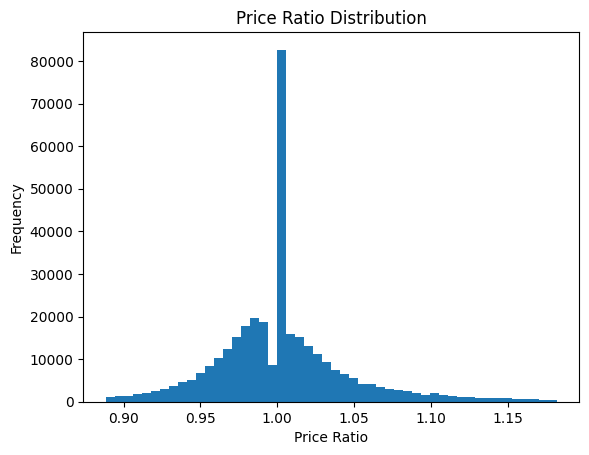

In [232]:
ratio = sold["PriceRatio"].replace([float("inf"), -float("inf")], None).dropna()

lower = ratio.quantile(0.01)
upper = ratio.quantile(0.99)

ratio_filtered = ratio[(ratio >= lower) & (ratio <= upper)]

ratio_filtered.plot.hist(bins=50)

plt.title("Price Ratio Distribution")
plt.xlabel("Price Ratio")
plt.ylabel("Frequency")

plt.show()

Most homes cluster around a ratio near 1, meaning many properties sell close to their listing price.

### 11. Visualize Price Per Square Foot Distribution

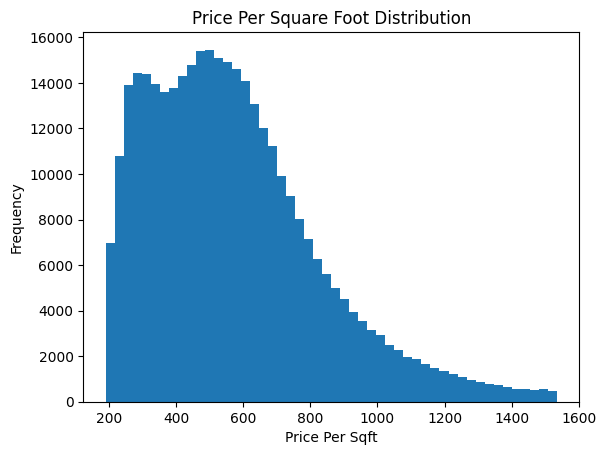

In [233]:
ppsqft = sold["PricePerSqft"].dropna()

lower = ppsqft.quantile(0.01)
upper = ppsqft.quantile(0.99)

ppsqft_filtered = ppsqft[(ppsqft >= lower) & (ppsqft <= upper)]

ppsqft_filtered.plot.hist(bins=50)

plt.title("Price Per Square Foot Distribution")
plt.xlabel("Price Per Sqft")
plt.ylabel("Frequency")

plt.show()

Price per square foot varies across homes due to differences in location, size, and property characteristics.

### 12. Visualize Days on Market Distribution

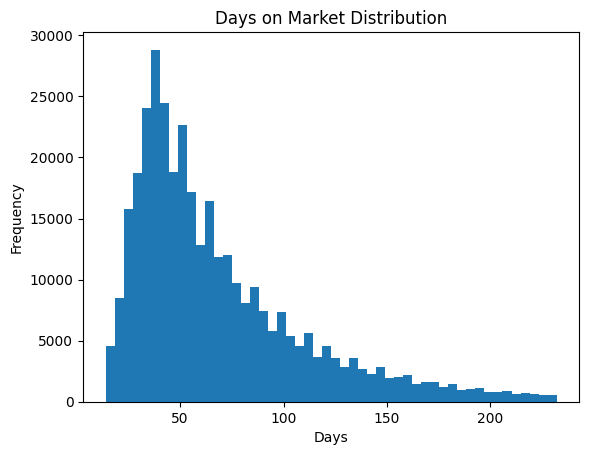

In [234]:
dom = sold["DaysOnMarket"].dropna()

lower = dom.quantile(0.01)
upper = dom.quantile(0.99)

dom_filtered = dom[(dom >= lower) & (dom <= upper)]

dom_filtered.plot.hist(bins=50)

plt.title("Days on Market Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

Most properties sell within a moderate time range, while fewer properties remain on the market for extended periods.

### 13. Segment Analysis by Property Type

In [235]:
if "PropertyType" in listed.columns:

    property_summary = listed.groupby("PropertyType")[["ListPrice"]].agg(
        ["mean", "median", "count"]
    )

    print(property_summary)

else:
    print("PropertyType column not found in listed dataset.")

                 ListPrice                  
                      mean    median   count
PropertyType                                
Residential   1.176013e+06  800000.0  443881


This grouped summary compares pricing patterns across property categories.

### 14. Segment Analysis by City

In [236]:
if "City" in sold.columns:

    city_summary = sold.groupby("City")[["ClosePrice"]].agg(
        ["mean", "median", "count"]
    ).sort_values(
        ("ClosePrice", "median"),
        ascending=False
    )

    print(city_summary.head(10))

else:
    print("City column not found.")

                   ClosePrice                 
                         mean     median count
City                                          
Hidden Hills     8.119826e+06  6900000.0    25
Atherton         7.158364e+06  6300000.0    33
Los Altos Hills  5.777343e+06  5405000.0    54
Hillsborough     5.552848e+06  5125000.0    81
Monte Sereno     4.972808e+06  4562500.0    26
Montecito        6.016992e+06  4547500.0    16
Bel Air          4.175632e+06  4375000.0    11
Rancho Santa Fe  4.858849e+06  4255750.0   364
Portola Valley   4.315991e+06  4025000.0    67
Los Altos        3.884657e+06  3935000.0   161


This summary identifies cities with the strongest median housing prices.

### 15. Save Updated Dataset

In [237]:
sold.to_csv("week6_engineered_dataset.csv", index=False)

print("Week 6 engineered dataset saved successfully.")

Week 6 engineered dataset saved successfully.


The engineered dataset was saved for future dashboard development and advanced market analysis.

### 16. Stakeholder Insights

- Real estate agents can use PriceRatio and PricePerSqft to guide pricing strategies  
- Sellers gain insight into negotiation strength and market timing  
- Buyers can better understand affordability and market competitiveness  

These engineered features support decision-making across the housing market.

### 17. Key Takeaways

1. Key market metrics were engineered from raw MLS data  
2. Time-series variables now support monthly and yearly trend analysis  
3. Pricing ratios provide insight into negotiation and competitiveness  
4. Segment analysis reveals differences across cities and property types  
5. The dataset is now prepared for Tableau dashboard creation

# Week 7 – Outlier Detection and Data Quality

### 1. Objective

The goal of Week 7 is to identify extreme values in key numeric fields using the Interquartile Range (IQR) method. Instead of deleting records immediately, outliers are first flagged so the full dataset is preserved. A separate filtered dataset is then created for analysis.

### 2. Create a Copy of the Dataset

In [238]:
week7_full = sold.copy()

print("Original dataset rows:", len(week7_full))

Original dataset rows: 354931


A copy of the sold dataset was created so outlier flags can be added while preserving the original records.

### 3. Apply IQR Outlier Flags

In [239]:
outlier_fields = ["ClosePrice", "LivingArea", "DaysOnMarket"]

for field in outlier_fields:
    if field in week7_full.columns:
        Q1 = week7_full[field].quantile(0.25)
        Q3 = week7_full[field].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        flag_column = field + "_outlier_flag"

        week7_full[flag_column] = (
            (week7_full[field] < lower) |
            (week7_full[field] > upper)
        )

        print(field)
        print("Lower bound:", lower)
        print("Upper bound:", upper)
        print("Outlier count:", week7_full[flag_column].sum())
        print()
    else:
        print(field, "not found in dataset.")

ClosePrice
Lower bound: -425000.0
Upper bound: 2255000.0
Outlier count: 24236

LivingArea
Lower bound: -185.5
Upper bound: 3626.5
Outlier count: 14665

DaysOnMarket
Lower bound: -37.0
Upper bound: 163.0
Outlier count: 18991



Outlier flag columns were created for `ClosePrice`, `LivingArea`, and `DaysOnMarket` using the IQR method. These flags identify extreme values without permanently removing them from the full dataset.

### 5. Create Clean Filtered Dataset

In [240]:
required_flag_columns = [
    "ClosePrice_outlier_flag",
    "LivingArea_outlier_flag",
    "DaysOnMarket_outlier_flag",
    "invalid_close_price_flag",
    "invalid_living_area_flag",
    "invalid_days_on_market_flag"
]

existing_flag_columns = [
    col for col in required_flag_columns
    if col in week7_full.columns
]

week7_clean = week7_full.copy()

for col in existing_flag_columns:
    week7_clean = week7_clean[week7_clean[col] == False]

print("Full flagged dataset rows:", len(week7_full))
print("Clean filtered dataset rows:", len(week7_clean))
print("Rows removed in clean filtered dataset:", len(week7_full) - len(week7_clean))

Full flagged dataset rows: 354931
Clean filtered dataset rows: 308222
Rows removed in clean filtered dataset: 46709


A clean filtered dataset was created by removing records flagged as outliers or invalid. The full flagged dataset is still preserved separately.

### 6. Compare Dataset Size Before and After Filtering

In [241]:
comparison = pd.DataFrame({
    "Dataset": ["Full flagged dataset", "Clean filtered dataset"],
    "Row Count": [len(week7_full), len(week7_clean)]
})

print(comparison)

                  Dataset  Row Count
0    Full flagged dataset     354931
1  Clean filtered dataset     308222


The row count comparison shows how many records were removed during filtering. This helps document the impact of outlier handling.

### 7. Compare Median Values Before and After Filtering

In [242]:
median_comparison = pd.DataFrame({
    "Metric": ["ClosePrice", "LivingArea", "DaysOnMarket"],
    "Before Filtering": [
        week7_full["ClosePrice"].median(),
        week7_full["LivingArea"].median(),
        week7_full["DaysOnMarket"].median()
    ],
    "After Filtering": [
        week7_clean["ClosePrice"].median(),
        week7_clean["LivingArea"].median(),
        week7_clean["DaysOnMarket"].median()
    ]
})

print(median_comparison)

         Metric  Before Filtering  After Filtering
0    ClosePrice          815000.0         780000.0
1    LivingArea            1633.0           1564.0
2  DaysOnMarket              55.0             53.0


Median values were compared before and after filtering to understand how removing extreme values changes the dataset. Median is used because it is less sensitive to outliers than the mean.

### 8. Visualize Before and After Filtering

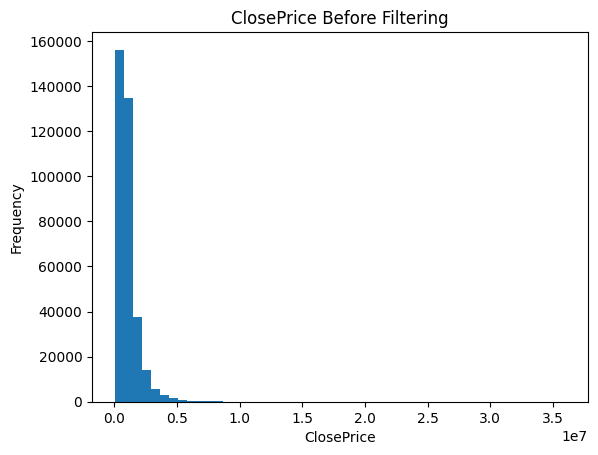

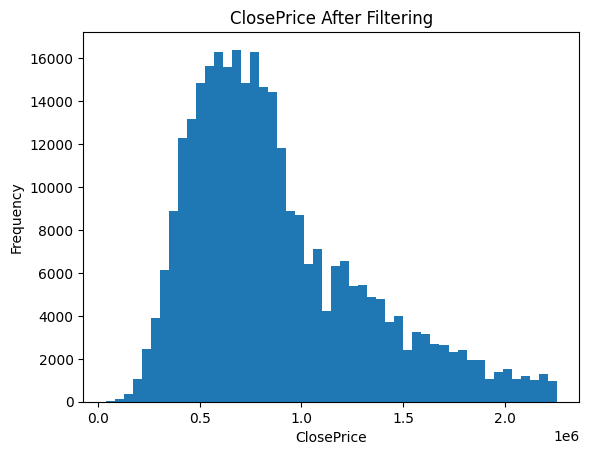

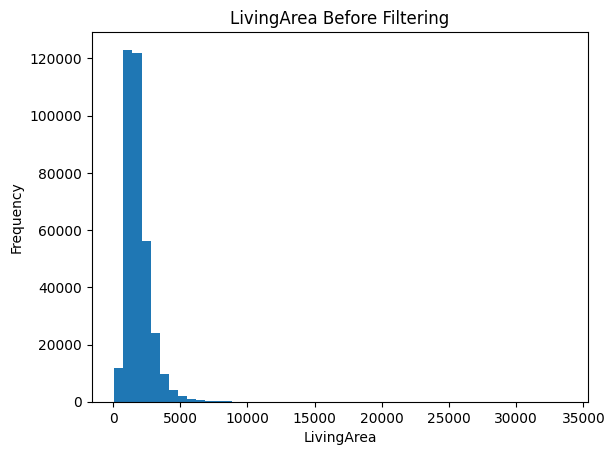

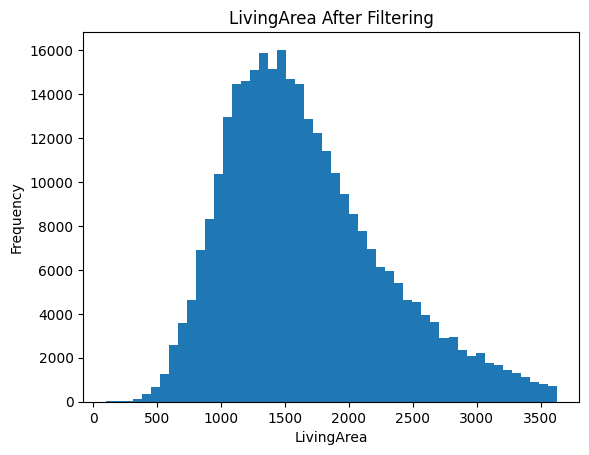

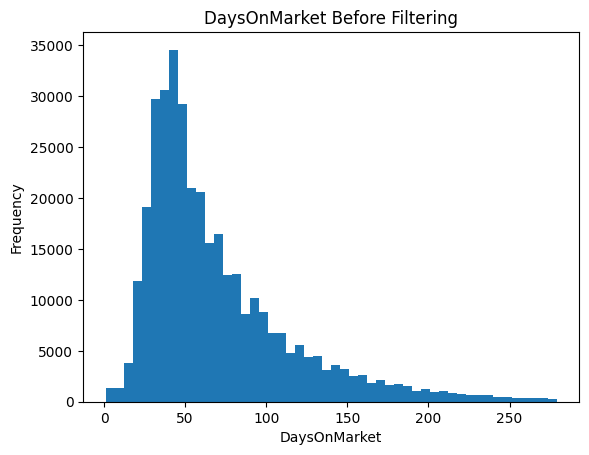

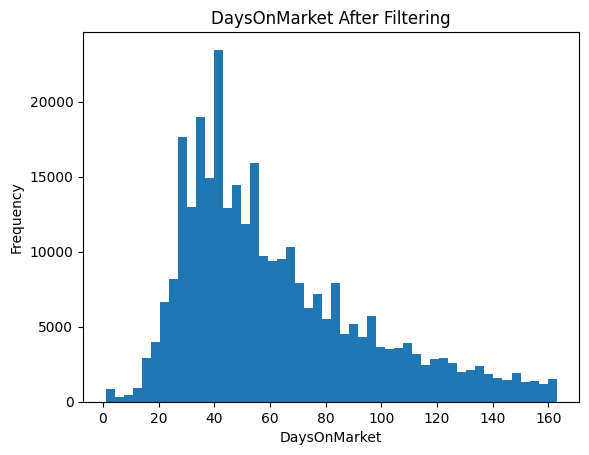

In [243]:
for field in ["ClosePrice", "LivingArea", "DaysOnMarket"]:
    if field in week7_full.columns:
        week7_full[field].dropna().plot.hist(bins=50)
        plt.title(field + " Before Filtering")
        plt.xlabel(field)
        plt.ylabel("Frequency")
        plt.show()

        week7_clean[field].dropna().plot.hist(bins=50)
        plt.title(field + " After Filtering")
        plt.xlabel(field)
        plt.ylabel("Frequency")
        plt.show()

The before-and-after histograms show how filtering improves the usability of the distributions by reducing the effect of extreme values.

### 9. Save Week 7 Outputs

In [244]:
week7_full.to_csv("week7_full_flagged_dataset.csv", index=False)
week7_clean.to_csv("week7_clean_filtered_dataset.csv", index=False)

print("Saved week7_full_flagged_dataset.csv")
print("Saved week7_clean_filtered_dataset.csv")

Saved week7_full_flagged_dataset.csv
Saved week7_clean_filtered_dataset.csv


Both datasets were saved. The full flagged dataset preserves all records with outlier indicators, while the clean filtered dataset is ready for analysis and Tableau use.

### 10. Week 7 Summary

The IQR method was applied to key numeric fields: `ClosePrice`, `LivingArea`, and `DaysOnMarket`. Outlier flags were created instead of immediately deleting records, which preserves the full dataset for transparency.

A separate clean filtered dataset was created by removing records flagged as outliers or invalid. Dataset size and median values were compared before and after filtering to document the impact of the cleaning process.